<a href="https://colab.research.google.com/github/julipolovinkina-hub/OOP_1/blob/main/OOP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# ЛАБОРАТОРНАЯ РАБОТА № 4.1
# Базовые классы без наследования + try-except
# ==========================================

class MenuItem:
    """Базовый класс для позиции меню ресторана."""

    def __init__(self, name: str, price: float, category: str = "Основное"):
        if not isinstance(name, str) or not name.strip():
            raise ValueError("Название блюда должно быть строкой и не может быть пустым.")
        if not isinstance(price, (int, float)) or price < 0:
            raise ValueError("Цена должна быть неотрицательным числом.")

        self.name = name.strip()
        self.price = float(price)
        self.category = category

    def display_info(self) -> None:
        """Выводит информацию о позиции меню."""
        print(f"[{self.category}] {self.name} — {self.price:.2f} руб.")

    def __str__(self) -> str:
        return f"Блюдо: {self.name} | Категория: {self.category} | Цена: {self.price:.2f} руб."


class Customer:
    """Базовый класс клиента ресторана."""

    def __init__(self, name: str, table_number: int, guests_count: int = 1):
        if not isinstance(name, str) or not name.strip():
            raise ValueError("Имя клиента должно быть строкой и не может быть пустым.")
        if not isinstance(table_number, int) or table_number <= 0:
            raise ValueError("Номер столика должен быть положительным целым числом.")
        if not isinstance(guests_count, int) or guests_count < 1:
            raise ValueError("Количество гостей должно быть не менее 1.")

        self.name = name.strip()
        self.table_number = table_number
        self.guests_count = guests_count

    def display_info(self) -> None:
        """Выводит информацию о клиенте."""
        print(f"Клиент {self.name} — столик №{self.table_number} (гостей: {self.guests_count})")

    def __str__(self) -> str:
        return f"Клиент: {self.name} | Столик: №{self.table_number} | Гостей: {self.guests_count}"


# ==========================================
# ДЕМОНСТРАЦИЯ (main)
# ==========================================

def main() -> None:
    """Демонстрация работы базовых классов и обработки исключений."""
    print("=" * 60)
    print("РЕСТОРАН 'PYTHON GOURMET'")
    print("=" * 60)

    # 1. Успешное создание объектов (внутри try-except для безопасности)
    print("\n---  Корректные позиции меню ---")
    try:
        dish_1 = MenuItem(name="Борщ", price=450.00, category="Супы")
        dish_2 = MenuItem(name="Стейк Рибай", price=1890.50, category="Горячее")
        dish_3 = MenuItem(name="Тирамису", price=390.00, category="Десерты")

        for dish in (dish_1, dish_2, dish_3):
            print(dish)
            dish.display_info()
    except ValueError as e:
        print(f"Ошибка при создании меню: {e}")

    # 2. Демонстрация обработки ошибок (намеренно некорректные данные)
    print("\n--- Демонстрация обработки ошибок (MenuItem) ---")
    invalid_dishes = [
        {"name": "", "price": 300.0, "category": "Тест"},          # Пустое имя
        {"name": "Салат", "price": -50.0, "category": "Тест"},     # Отрицательная цена
        {"name": "Паста", "price": "двести", "category": "Тест"}   # Не число
    ]

    for i, data in enumerate(invalid_dishes, 1):
        try:
            print(f"Попытка {i}: {data}")
            dish = MenuItem(**data)
            print(f" Успешно: {dish}")
        except (ValueError, TypeError) as e:
            print(f"Ошибка: {e}")

    # 3. Клиенты (успешное создание)
    print("\n--- Корректные клиенты ---")
    try:
        customer_1 = Customer(name="Иван Петров", table_number=5, guests_count=2)
        customer_2 = Customer(name="Мария Сидорова", table_number=12, guests_count=4)

        for client in (customer_1, customer_2):
            print(client)
            client.display_info()
    except ValueError as e:
        print(f"Ошибка при создании клиента: {e}")

    # 4. Демонстрация обработки ошибок (Customer)
    print("\n--- Демонстрация обработки ошибок (Customer) ---")
    try:
        print("Попытка создания клиента с отрицательным номером столика и 0 гостей...")
        bad_customer = Customer(name="Аноним", table_number=-1, guests_count=0)
        print(f"Успешно: {bad_customer}")
    except ValueError as e:
        print(f"Ошибка: {e}")


if __name__ == "__main__":
    main()

РЕСТОРАН 'PYTHON GOURMET'

---  Корректные позиции меню ---
Блюдо: Борщ | Категория: Супы | Цена: 450.00 руб.
[Супы] Борщ — 450.00 руб.
Блюдо: Стейк Рибай | Категория: Горячее | Цена: 1890.50 руб.
[Горячее] Стейк Рибай — 1890.50 руб.
Блюдо: Тирамису | Категория: Десерты | Цена: 390.00 руб.
[Десерты] Тирамису — 390.00 руб.

--- Демонстрация обработки ошибок (MenuItem) ---
Попытка 1: {'name': '', 'price': 300.0, 'category': 'Тест'}
Ошибка: Название блюда должно быть строкой и не может быть пустым.
Попытка 2: {'name': 'Салат', 'price': -50.0, 'category': 'Тест'}
Ошибка: Цена должна быть неотрицательным числом.
Попытка 3: {'name': 'Паста', 'price': 'двести', 'category': 'Тест'}
Ошибка: Цена должна быть неотрицательным числом.

--- Корректные клиенты ---
Клиент: Иван Петров | Столик: №5 | Гостей: 2
Клиент Иван Петров — столик №5 (гостей: 2)
Клиент: Мария Сидорова | Столик: №12 | Гостей: 4
Клиент Мария Сидорова — столик №12 (гостей: 4)

--- Демонстрация обработки ошибок (Customer) ---
Попытк

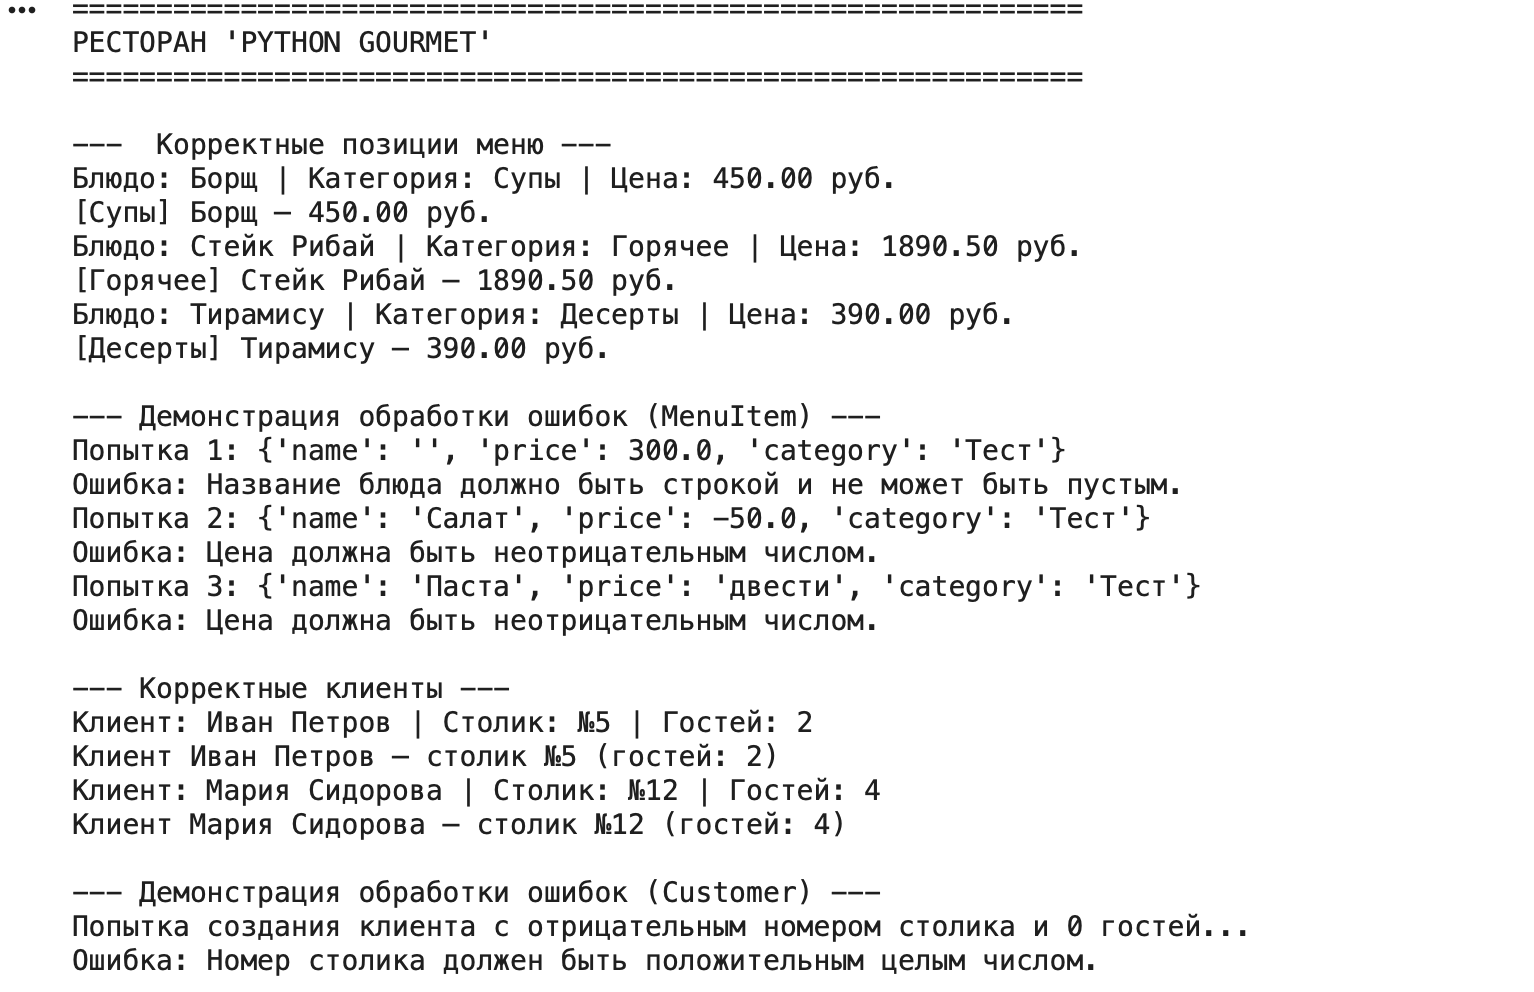